# Seaborn

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns

In [4]:
# Copy of USA DA'S
df_da_usa = df[(df['job_title_short']=='Data Analyst') & (df['job_location']=='United States')].copy()

#Clean na salaries
df_da_usa = df_da_usa.dropna(subset=['salary_year_avg'])

In [5]:
#Explode skills
df_da_usa = df_da_usa.explode('job_skills')

In [6]:
df_DA_top_pay = df_da_usa.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)
df_DA_top_pay

,count,median
job_skills,,
pytorch,1,220000.0
jira,1,190000.0
atlassian,1,190000.0
unity,1,169833.5
git,1,147500.0
snowflake,2,132225.0
perl,1,119550.0
spss,1,119550.0
qlik,1,119550.0


In [7]:
df_DA_skills = df_da_usa.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)
df_DA_skills

,count,median
job_skills,,
power bi,10,106400.00
sql server,3,105000.00
python,15,100000.00
sas,4,93525.00
tableau,16,88500.00
sql,20,88500.00
r,8,88500.00
excel,14,82258.75
sharepoint,5,77017.50


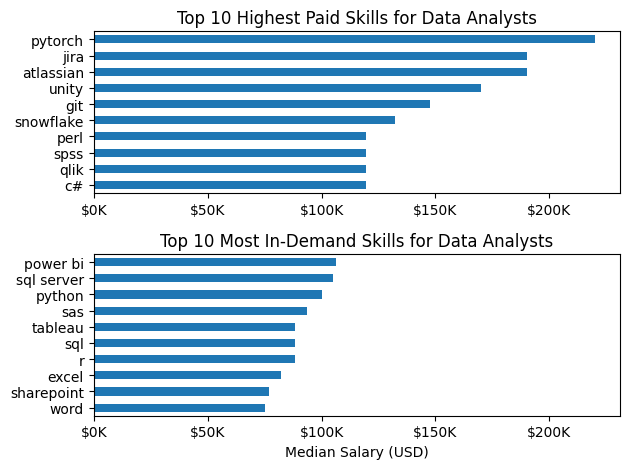

In [8]:
fig, ax = plt.subplots(2, 1)  

# Top 10 Highest Paid Skills for Data Analysts
df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

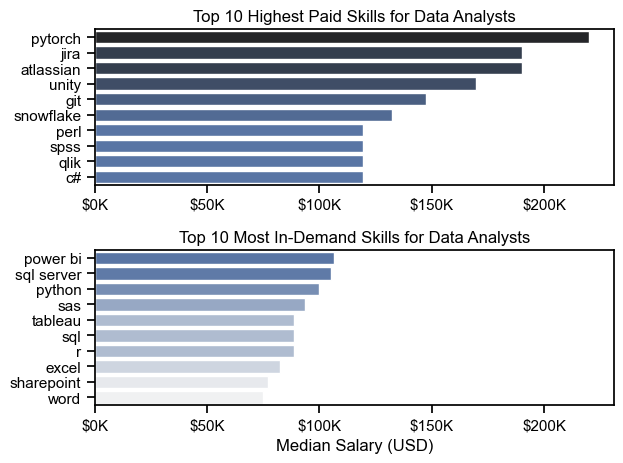

In [17]:
fig, ax = plt.subplots(2, 1)  

sns.set_theme(style="ticks")

# Top 10 Highest Paid Skills for Data Analysts

sns.barplot(data= df_DA_top_pay, x = 'median', y = df_DA_top_pay.index, ax=ax[0], hue = 'median', palette = 'dark:b_r' )
ax[0].legend().remove()
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts

sns.barplot(data= df_DA_skills, x = 'median', y = df_DA_skills.index, ax=ax[1], hue = 'median', palette = 'light:b' )
ax[1].legend().remove()
# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

# Histogram

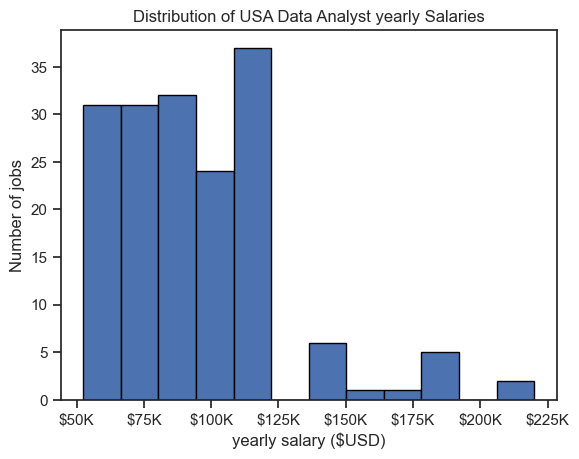

In [24]:
df_da_usa['salary_year_avg'].plot(kind='hist', bins = 12, edgecolor = 'black')
plt.title('Distribution of USA Data Analyst yearly Salaries')
plt.xlabel('yearly salary ($USD)')
plt.ylabel('Number of jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

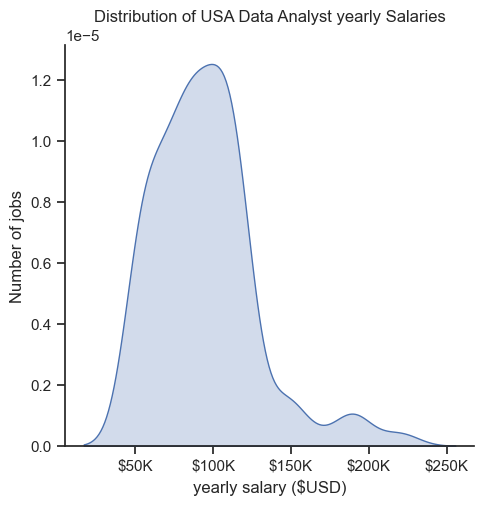

In [27]:

sns.displot(df_da_usa['salary_year_avg'], kind = 'kde', fill = True)

plt.title('Distribution of USA Data Analyst yearly Salaries')
plt.xlabel('yearly salary ($USD)')
plt.ylabel('Number of jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

C:\Users\jhonn\AppData\Local\Temp\ipykernel_4516\2335858468.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert = False)


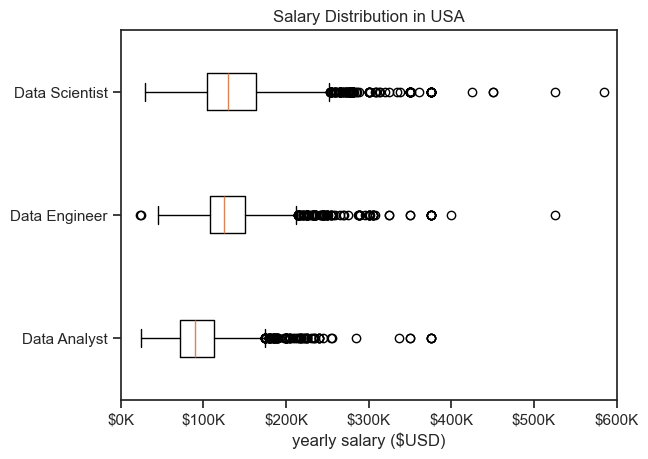

In [31]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].copy()

df_us = df_us.dropna(subset=['salary_year_avg'])

job_list = [ df_us[df_us['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert = False)
plt.title('Salary Distribution in USA')
plt.xlabel('yearly salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

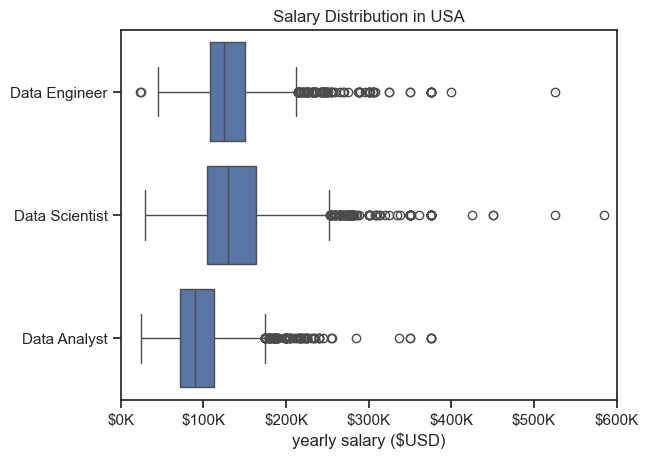

In [34]:

sns.boxplot(data=df_us, x= 'salary_year_avg', y= 'job_title_short')

plt.title('Salary Distribution in USA')
plt.xlabel('yearly salary ($USD)')
plt.ylabel("")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()